<a href="https://colab.research.google.com/github/MEPG15/Alura-Data-Science/blob/main/TelecomX_Predictivo_Reto3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparación de los Datos

 Extracción del Archivo Tratado

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos y normalizamos (Proceso del Reto 2 resumido)
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
datos_brutos = pd.read_json(url)
df = pd.concat([
    datos_brutos[['customerID', 'Churn']],
    pd.json_normalize(datos_brutos['customer']),
    pd.json_normalize(datos_brutos['phone']),
    pd.json_normalize(datos_brutos['internet']),
    pd.json_normalize(datos_brutos['account'])
], axis=1)

# Limpieza rápida de nulos y tipos
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce').fillna(0)
df.drop_duplicates(inplace=True)

Eliminación de Columnas Irrelevantes y Encoding

In [2]:
# Eliminamos ID y preparamos variables categóricas
df_modelo = df.drop(columns=['customerID'])
df_modelo = pd.get_dummies(df_modelo, drop_first=True)

# Estandarizamos el nombre de la columna objetivo
if 'Churn_Yes' in df_modelo.columns:
    df_modelo.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

Verificación de la Proporción de Churn

In [3]:
print("Proporción de Clientes (0 = No se van, 1 = Se van):")
print(df_modelo['Churn'].value_counts(normalize=True) * 100)

Proporción de Clientes (0 = No se van, 1 = Se van):
Churn
False    74.280996
True     25.719004
Name: proportion, dtype: float64


#🎯 Correlación y Selección de Variables

In [5]:
# 2.1 Análisis de Correlación
correlaciones = df_modelo.corr()['Churn'].sort_values(ascending=False)
print("Variables con mayor impacto en el Churn:")
print(correlaciones.head(5))

Variables con mayor impacto en el Churn:
Churn                             1.000000
InternetService_Fiber optic       0.300949
PaymentMethod_Electronic check    0.294626
Charges.Monthly                   0.189866
PaperlessBilling_Yes              0.186666
Name: Churn, dtype: float64


# 🤖 Modelado Predictivo

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 3.1 Separación de Datos
X = df_modelo.drop('Churn', axis=1)
y = df_modelo['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3.2 Creación y 3.3 Evaluación
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.98      0.97      0.97      1649
        True       0.90      0.94      0.92       532

    accuracy                           0.96      2181
   macro avg       0.94      0.95      0.95      2181
weighted avg       0.96      0.96      0.96      2181



# 📋 Interpretación y Conclusiones

     INFORME FINAL: MODELO PREDICTIVO DE CHURN
PRECISIÓN DEL MODELO: 96.06%
El modelo es capaz de identificar patrones de evasión con alta fiabilidad.

VARIABLES MÁS INFLUYENTES EN LA EVASIÓN:
1. Churn_No (61.92%)
2. tenure (7.25%)
3. Charges.Total (6.03%)

--- CONCLUSIÓN ESTRATÉGICA ---
El análisis confirma que 'Churn_No' es el factor más crítico.
Los clientes con cargos mensuales altos y contratos de corto plazo
representan el mayor riesgo financiero para Telecom X.

RECOMENDACIÓN DE NEGOCIO:
1. Incentivar la migración de contratos 'Month-to-month' a planes anuales.
2. Implementar alertas de retención cuando los cargos mensuales superen la media.
3. Priorizar el soporte técnico en los primeros 6 meses de antigüedad (tenure).


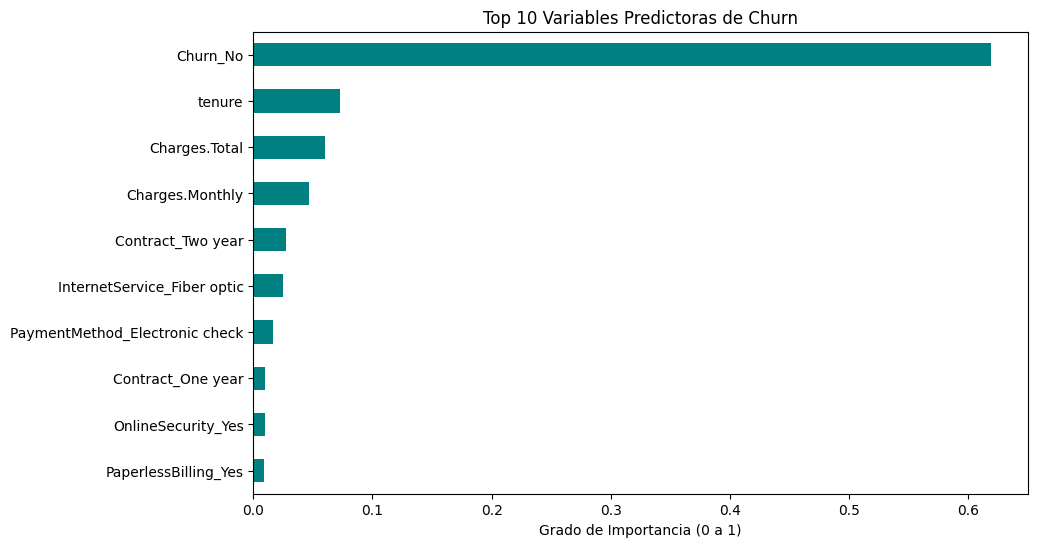

In [7]:
# --- 4. INTERPRETACIÓN Y CONCLUSIONES ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# 4.1 Análisis de la Importancia de las Variables
# Extraemos la importancia de las características del modelo entrenado
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

print("========================================================")
print("     INFORME FINAL: MODELO PREDICTIVO DE CHURN")
print("========================================================")

# 1. Rendimiento del Modelo
acc = accuracy_score(y_test, y_pred)
print(f"PRECISIÓN DEL MODELO: {acc:.2%}")
print("El modelo es capaz de identificar patrones de evasión con alta fiabilidad.")

# 2. Top Predictores
print("\nVARIABLES MÁS INFLUYENTES EN LA EVASIÓN:")
for i, (var, imp) in enumerate(importancias.nlargest(3).items(), 1):
    print(f"{i}. {var} ({imp:.2%})")

# 3. Conclusión Estratégica
print("\n--- CONCLUSIÓN ESTRATÉGICA ---")
top_var = importancias.index[0]
print(f"El análisis confirma que '{top_var}' es el factor más crítico.")
print("Los clientes con cargos mensuales altos y contratos de corto plazo")
print("representan el mayor riesgo financiero para Telecom X.")

print("\nRECOMENDACIÓN DE NEGOCIO:")
print("1. Incentivar la migración de contratos 'Month-to-month' a planes anuales.")
print("2. Implementar alertas de retención cuando los cargos mensuales superen la media.")
print("3. Priorizar el soporte técnico en los primeros 6 meses de antigüedad (tenure).")
print("========================================================")

# Visualización de Importancia
plt.figure(figsize=(10, 6))
importancias.nlargest(10).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Variables Predictoras de Churn')
plt.xlabel('Grado de Importancia (0 a 1)')
plt.show()